<a href="https://colab.research.google.com/github/Fardous-bp/CNS-doped-Al-interconnect-alloy/blob/main/CNS_Al_6_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install matcalc

!pip install matgl
!pip install seekpath

!pip install crystal-toolkit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.6/566.6 kB 10.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 761.9/761.9 kB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.0/94.0 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.7/755.7 kB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
from pymatgen.core import Structure

# include the folder path like ".cif"
my_cif_file = "CuNi2Sn.cif"

if os.path.exists(my_cif_file):
    my_structure = Structure.from_file(my_cif_file)
    print(f"SUCCESS: {my_cif_file} loaded successfully.")
    print(my_structure)
else:
    print(f"ERROR: File '{my_cif_file}' not found. Please check the name in your Colab files tab.")

SUCCESS: CuNi2Sn.cif loaded successfully.
Full Formula (Cu4 Ni8 Sn4)
Reduced Formula: CuNi2Sn
abc   :   5.975124   5.975124   5.975124
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (16)
  #  SP       a     b     c
---  ----  ----  ----  ----
  0  Cu    0     0     0
  1  Cu    0     0.5   0.5
  2  Cu    0.5   0     0.5
  3  Cu    0.5   0.5   0
  4  Ni    0.25  0.75  0.75
  5  Ni    0.25  0.25  0.75
  6  Ni    0.25  0.25  0.25
  7  Ni    0.25  0.75  0.25
  8  Ni    0.75  0.75  0.25
  9  Ni    0.75  0.25  0.25
 10  Ni    0.75  0.25  0.75
 11  Ni    0.75  0.75  0.75
 12  Sn    0     0     0.5
 13  Sn    0     0.5   0
 14  Sn    0.5   0     0
 15  Sn    0.5   0.5   0.5


In [ ]:
 # The value 0.2 adds random noise (in Angstroms) to the atomic sites
cuni2sn_perturbed = my_structure.copy()
cuni2sn_perturbed.perturb(0.2)

# 2. Expand the lattice volume
# Multiplying by 1.2 increases the total cell volume by 20%
cuni2sn_perturbed.scale_lattice(my_structure.volume * 1.2)

# 3. View the results
print("Perturbed CuNi2Sn Structure:")
print(cuni2sn_perturbed)
cuni2sn_perturbed

Perturbed CuNi2Sn Structure:
Full Formula (Cu4 Ni8 Sn4)
Reduced Formula: CuNi2Sn
abc   :   6.349517   6.349517   6.349517
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (16)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Cu    0.991261  0.996611  0.984966
  1  Cu    0.019876  0.521077  0.505278
  2  Cu    0.514947  0.002197  0.507201
  3  Cu    0.508564  0.50295   0.021014
  4  Ni    0.249262  0.734833  0.750264
  5  Ni    0.249316  0.260393  0.737888
  6  Ni    0.250919  0.247607  0.26618
  7  Ni    0.25557   0.745564  0.250497
  8  Ni    0.738193  0.75611   0.257843
  9  Ni    0.771893  0.253925  0.237958
 10  Ni    0.760683  0.23239   0.769848
 11  Ni    0.74477   0.754229  0.763696
 12  Sn    0.011009  0.01092   0.518968
 13  Sn    0.990935  0.495519  0.00272
 14  Sn    0.520783  0.00675   0.010146
 15  Sn    0.496756  0.498374  0.495256


Structure Summary
Lattice
    abc : 6.349516720528679 6.349516720528679 6.349516720528679
 angles : 90.0 90.0 90.0
 volume : 255.98941833973996
      A : np.float64(6.349516720528679) np.float64(0.0) np.float64(3.887957663964023e-16)
      B : np.float64(1.0210801652782683e-15) np.float64(6.349516720528679) np.float64(3.887957663964023e-16)
      C : np.float64(0.0) np.float64(0.0) np.float64(6.349516720528679)
    pbc : True True True
PeriodicSite: Cu0 (Cu) (6.294, 6.328, 6.254) [0.9913, 0.9966, 0.985]
PeriodicSite: Cu1 (Cu) (0.1262, 3.309, 3.208) [0.01988, 0.5211, 0.5053]
PeriodicSite: Cu2 (Cu) (3.27, 0.01395, 3.22) [0.5149, 0.002197, 0.5072]
PeriodicSite: Cu3 (Cu) (3.229, 3.193, 0.1334) [0.5086, 0.5029, 0.02101]
PeriodicSite: Ni4 (Ni) (1.583, 4.666, 4.764) [0.2493, 0.7348, 0.7503]
PeriodicSite: Ni5 (Ni) (1.583, 1.653, 4.685) [0.2493, 0.2604, 0.7379]
PeriodicSite: Ni6 (Ni) (1.593, 1.572, 1.69) [0.2509, 0.2476, 0.2662]
PeriodicSite: Ni7 (Ni) (1.623, 4.734, 1.591) [0.2556, 0.7456, 0.25

In [ ]:
import matcalc
from matcalc.utils import UNIVERSAL_CALCULATORS

import pprint
pprint.pprint(list(UNIVERSAL_CALCULATORS))  # calculators that come with bundled with matgl

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


[<UNIVERSAL_CALCULATORS.CHGNet: 'CHGNet'>,
 <UNIVERSAL_CALCULATORS.CHGNet-PES-MatPES-PBE-2025.2.10: 'CHGNet-PES-MatPES-PBE-2025.2.10'>,
 <UNIVERSAL_CALCULATORS.CHGNet-PES-MatPES-r2SCAN-2025.2.10: 'CHGNet-PES-MatPES-r2SCAN-2025.2.10'>,
 <UNIVERSAL_CALCULATORS.DeePMD: 'DeePMD'>,
 <UNIVERSAL_CALCULATORS.FAIRChem: 'FAIRChem'>,
 <UNIVERSAL_CALCULATORS.GRACE: 'GRACE'>,
 <UNIVERSAL_CALCULATORS.M3GNet: 'M3GNet'>,
 <UNIVERSAL_CALCULATORS.M3GNet-PES-ANI-1x-Subset: 'M3GNet-PES-ANI-1x-Subset'>,
 <UNIVERSAL_CALCULATORS.M3GNet-PES-MatPES-PBE-2025.2: 'M3GNet-PES-MatPES-PBE-2025.2'>,
 <UNIVERSAL_CALCULATORS.M3GNet-PES-MatPES-r2SCAN-2025.2: 'M3GNet-PES-MatPES-r2SCAN-2025.2'>,
 <UNIVERSAL_CALCULATORS.MACE: 'MACE'>,
 <UNIVERSAL_CALCULATORS.MatterSim: 'MatterSim'>,
 <UNIVERSAL_CALCULATORS.ORB: 'ORB'>,
 <UNIVERSAL_CALCULATORS.PBE: 'PBE'>,
 <UNIVERSAL_CALCULATORS.PETMAD: 'PETMAD'>,
 <UNIVERSAL_CALCULATORS.QET-PES-MatPES-PBE-2025.2: 'QET-PES-MatPES-PBE-2025.2'>,
 <UNIVERSAL_CALCULATORS.QET-PES-MatPES-r2SCAN-

In [ ]:
from matcalc.utils import MODEL_ALIASES
pprint.pprint(MODEL_ALIASES)  # list of all "aliased" models

{'chgnet': 'CHGNet-PES-MatPES-PBE-2025.1',
 'm3gnet': 'M3GNet-PES-MatPES-PBE-2025.1',
 'pbe': 'TensorNet-PES-MatPES-PBE-2025.2',
 'r2scan': 'TensorNet-PES-MatPES-r2SCAN-2025.2',
 'tensornet': 'TensorNet-PES-MatPES-PBE-2025.2'}


In [ ]:
calculator_pbe = matcalc.load_fp("pbe")
# calculator_pbe = matcalc.load_fp("TensorNet-MatPES-PBE-v2025.1-PES")

model.pt:   0%|          | 0.00/4.50k [00:00<?, ?B/s]

state.pt:   0%|          | 0.00/3.40M [00:00<?, ?B/s]

model.json: 0.00B [00:00, ?B/s]

In [ ]:
# Initialize the Relaxer exactly like the notebook
relax_calc = matcalc.RelaxCalc(
    calculator_pbe,
    optimizer="FIRE",
    relax_atoms=True,
    relax_cell=True,
)

# This should now complete in 1-3 minutes
print("Starting structural optimization...")
data = relax_calc.calc(cuni2sn_perturbed)

# Output results
print(f"Optimization Successful!")
print(f"Final Energy: {data['energy']:.4f} eV")
print(f"Final Optimized Volume: {data['final_structure'].volume:.2f} A^3")

Starting structural optimization...
Optimization Successful!
Final Energy: -75.9510 eV
Final Optimized Volume: 214.08 A^3


In [ ]:
pprint.pprint(data)

{'a': 5.98250559549921,
 'alpha': 90.04171055952423,
 'b': 5.982538791546256,
 'beta': 90.03239243352029,
 'c': 5.981547869560281,
 'energy': -75.95099639892578,
 'final_structure': Structure Summary
Lattice
    abc : 5.98250559549921 5.982538791546256 5.981547869560281
 angles : 90.04171055952423 90.03239243352029 89.90185213806097
 volume : 214.08261358393978
      A : np.float64(5.982503162655492) np.float64(0.00512373539521887) np.float64(-0.0016900686339307092)
      B : np.float64(0.005123729528011828) np.float64(5.982536201489976) np.float64(-0.0021766059227407175)
      C : np.float64(-0.001690033998172231) np.float64(-0.002176794640157258) np.float64(5.981547234720404)
    pbc : True True True
PeriodicSite: Cu (6.035, 5.979, 5.993) [1.008, 0.9988, 1.003]
PeriodicSite: Cu (0.006221, 3.007, 3.017) [0.0007518, 0.5027, 0.5045]
PeriodicSite: Cu (3.006, 0.02914, 3.017) [0.5026, 0.004624, 0.5046]
PeriodicSite: Cu (3.025, 2.974, 0.04793) [0.5052, 0.4967, 0.008337]
PeriodicSite: Ni (1.

In [ ]:
final_structure_pbe = data["final_structure"]
print(final_structure_pbe)
final_structure_pbe

Full Formula (Cu4 Ni8 Sn4)
Reduced Formula: CuNi2Sn
abc   :   5.982506   5.982539   5.981548
angles:  90.041711  90.032392  89.901852
pbc   :       True       True       True
Sites (16)
  #  SP           a          b         c
---  ----  --------  ---------  --------
  0  Cu    1.00822    0.998844  1.00257
  1  Cu    0.000752   0.502749  0.504529
  2  Cu    0.502593   0.004624  0.50456
  3  Cu    0.505152   0.496676  0.008337
  4  Ni    0.263956   0.747285  0.754516
  5  Ni    0.25285    0.256131  0.753432
  6  Ni    0.246287   0.250797  0.257149
  7  Ni    0.257158   0.752487  0.25635
  8  Ni    0.753774   0.755245  0.251429
  9  Ni    0.760877   0.245145  0.255584
 10  Ni    0.756045   0.253684  0.754917
 11  Ni    0.747642   0.750364  0.756456
 12  Sn    0.004758  -0.004007  0.510821
 13  Sn    1.00471    0.504759  0.004748
 14  Sn    0.502774   0.006457  0.004815
 15  Sn    0.507181   0.498208  0.499509


Structure Summary
Lattice
    abc : 5.98250559549921 5.982538791546256 5.981547869560281
 angles : 90.04171055952423 90.03239243352029 89.90185213806097
 volume : 214.08261358393978
      A : np.float64(5.982503162655492) np.float64(0.00512373539521887) np.float64(-0.0016900686339307092)
      B : np.float64(0.005123729528011828) np.float64(5.982536201489976) np.float64(-0.0021766059227407175)
      C : np.float64(-0.001690033998172231) np.float64(-0.002176794640157258) np.float64(5.981547234720404)
    pbc : True True True
PeriodicSite: Cu (6.035, 5.979, 5.993) [1.008, 0.9988, 1.003]
PeriodicSite: Cu (0.006221, 3.007, 3.017) [0.0007518, 0.5027, 0.5045]
PeriodicSite: Cu (3.006, 0.02914, 3.017) [0.5026, 0.004624, 0.5046]
PeriodicSite: Cu (3.025, 2.974, 0.04793) [0.5052, 0.4967, 0.008337]
PeriodicSite: Ni (1.582, 4.47, 4.511) [0.264, 0.7473, 0.7545]
PeriodicSite: Ni (1.513, 1.532, 4.506) [0.2529, 0.2561, 0.7534]
PeriodicSite: Ni (1.474, 1.501, 1.537) [0.2463, 0.2508, 0.2571]
PeriodicSite

In [ ]:
from matcalc import ElasticityCalc

# Use the 'final_structure_pbe'
multiplier_GPa = 160.2176621
elastic_calc = ElasticityCalc(calculator_pbe, relax_structure=False)
elastic_results = elastic_calc.calc(final_structure_pbe)

print(f"Bulk Modulus: {elastic_results['bulk_modulus_vrh'] * multiplier_GPa:.2f} GPa")
print(f"Shear Modulus: {elastic_results['shear_modulus_vrh'] * multiplier_GPa:.2f} GPa")

Bulk Modulus: 143.59 GPa
Shear Modulus: 37.90 GPa


Calculating Phonon Data for Pure CuNi2Sn...


/usr/local/lib/python3.12/dist-packages/matcalc/_phonon.py:203: PrimitiveMatrixAutoDefaultWarning: primitive_matrix defaulted to 'auto' and was resolved to a non-identity matrix:
  [-0.00000, -1.00000,  0.00000]
  [ 0.00000, -0.00000, -1.00000]
  [ 1.00000,  0.00000,  0.00000]
This differs from phonopy v3, whose default was the identity matrix. Pass primitive_matrix='P' (or --pa P on the command line) to restore the v3 behaviour.
  phonon = phonopy.Phonopy(cell, supercell_matrix=supercell_matrix, symprec=self.symprec, primitive_matrix="auto")


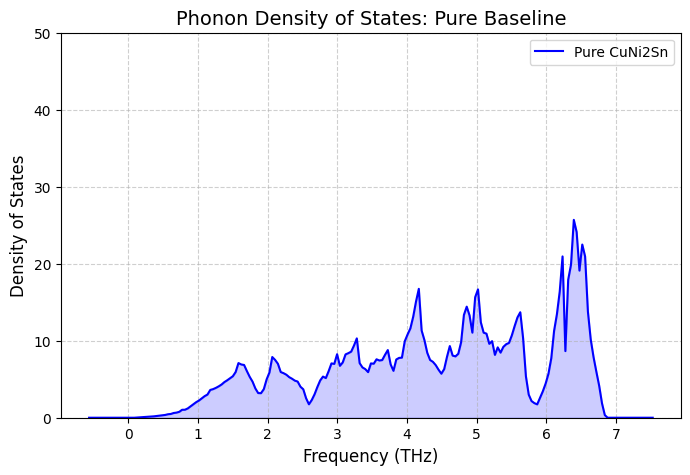

In [ ]:
from matcalc import PhononCalc
import matplotlib.pyplot as plt

# 1. Initialize for the pure structure
phonon_calc = PhononCalc(
    calculator_pbe,
    supercell_matrix=((2, 0, 0), (0, 2, 0), (0, 0, 2)),
    relax_structure=False
)

print("Calculating Phonon Data for Pure CuNi2Sn...")
pure_phonon_data = phonon_calc.calc(final_structure_pbe)

# 2. Access the Phonopy object
ph = pure_phonon_data["phonon"]

# 3. Trigger the DOS calculation (Fixes the AttributeError)
# We use a mesh of 20x20x20 for Q1-level resolution
ph.run_mesh([20, 20, 20])
ph.run_total_dos()

# 4. Extract frequencies and densities
# get_total_dos_dict() returns a dictionary with 'frequency-points' and 'total-dos'
dos_dict = ph.get_total_dos_dict()
freqs = dos_dict['frequency_points']
densities = dos_dict['total_dos']

# 5. Visualization
plt.figure(figsize=(8, 5))
plt.plot(freqs, densities, color='blue', label='Pure CuNi2Sn')
plt.fill_between(freqs, densities, color='blue', alpha=0.2)
plt.ylim(0, 50)
plt.title("Phonon Density of States: Pure Baseline", fontsize=14)
plt.xlabel("Frequency (THz)", fontsize=12)
plt.ylabel("Density of States", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [ ]:
# First 'Doped' version of structure
sac_al_structure = final_structure_pbe.copy()

# Replace one Sn site (index 12) with Al to simulate doping
sac_al_structure.replace(12, "Al")

# NOW: Run the Relaxation and Elasticity cells again for this NEW structure

Structure Summary
Lattice
    abc : 5.98250559549921 5.982538791546256 5.981547869560281
 angles : 90.04171055952423 90.03239243352029 89.90185213806097
 volume : 214.08261358393978
      A : np.float64(5.982503162655492) np.float64(0.00512373539521887) np.float64(-0.0016900686339307092)
      B : np.float64(0.005123729528011828) np.float64(5.982536201489976) np.float64(-0.0021766059227407175)
      C : np.float64(-0.001690033998172231) np.float64(-0.002176794640157258) np.float64(5.981547234720404)
    pbc : True True True
PeriodicSite: Cu (6.035, 5.979, 5.993) [1.008, 0.9988, 1.003]
PeriodicSite: Cu (0.006221, 3.007, 3.017) [0.0007518, 0.5027, 0.5045]
PeriodicSite: Cu (3.006, 0.02914, 3.017) [0.5026, 0.004624, 0.5046]
PeriodicSite: Cu (3.025, 2.974, 0.04793) [0.5052, 0.4967, 0.008337]
PeriodicSite: Ni (1.582, 4.47, 4.511) [0.264, 0.7473, 0.7545]
PeriodicSite: Ni (1.513, 1.532, 4.506) [0.2529, 0.2561, 0.7534]
PeriodicSite: Ni (1.474, 1.501, 1.537) [0.2463, 0.2508, 0.2571]
PeriodicSite

In [ ]:
print("Optimizing the Al-doped SAC alloy...")
doped_results = relax_calc.calc(sac_al_structure)
optimized_doped_structure = doped_results["final_structure"]

print(f"Doped Energy: {doped_results['energy']:.4f} eV")

Optimizing the Al-doped SAC alloy...
Doped Energy: -76.7458 eV


In [ ]:
# Calculate Elastic Moduli for the doped structure
doped_elastic_results = elastic_calc.calc(optimized_doped_structure)

# Unit conversion (eV/A^3 to GPa)
multiplier_GPa = 160.2176621
doped_bulk = doped_elastic_results['bulk_modulus_vrh'] * multiplier_GPa

print(f"Al-Doped Bulk Modulus: {doped_bulk:.2f} GPa")
# Calculate the % change compared to pure structure results

Al-Doped Bulk Modulus: 142.26 GPa


In [ ]:
# 1. Calculate the Shear Modulus for the Doped structure
# We use the same multiplier for GPa conversion
multiplier_GPa = 160.2176621
doped_shear = doped_elastic_results['shear_modulus_vrh'] * multiplier_GPa

print(f"Al-Doped Shear Modulus: {doped_shear:.2f} GPa")
print(f"Pure Shear Modulus: 37.64 GPa")

Al-Doped Shear Modulus: 40.94 GPa
Pure Shear Modulus: 37.64 GPa


Calculating Phonon Data for Al-Doped CuNi2Sn...


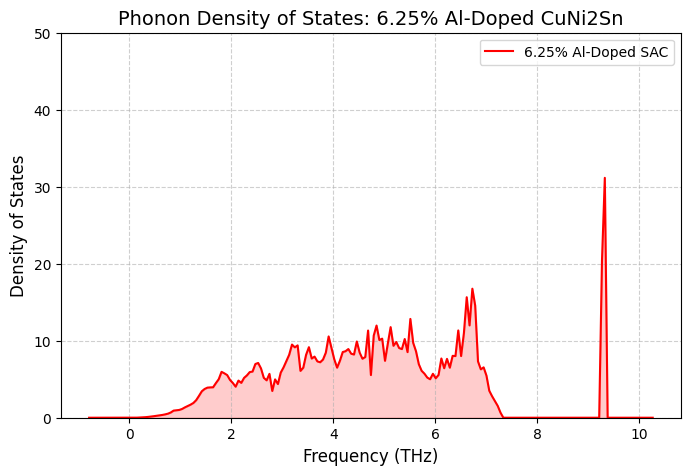

In [ ]:
from matcalc import PhononCalc
import matplotlib.pyplot as plt

# 1. Initialize for the optimized doped structure
# Ensure we use the exact same supercell_matrix as the pure one (2x2x2)
phonon_calc_doped = PhononCalc(
    calculator_pbe,
    supercell_matrix=((2, 0, 0), (0, 2, 0), (0, 0, 2)),
    relax_structure=False
)

print("Calculating Phonon Data for Al-Doped CuNi2Sn...")
# Use the final relaxed structure from your previous doping run
doped_phonon_data = phonon_calc_doped.calc(optimized_doped_structure)

# 2. Access the Phonopy object
ph_doped = doped_phonon_data["phonon"]

# 3. Trigger the DOS calculation
# High-resolution mesh (20x20x20)
ph_doped.run_mesh([20, 20, 20])
ph_doped.run_total_dos()

# 4. Extract frequencies and densities
dos_dict_doped = ph_doped.get_total_dos_dict()
freqs_doped = dos_dict_doped['frequency_points']
densities_doped = dos_dict_doped['total_dos']

# 5. Visualization for Your Paper
plt.figure(figsize=(8, 5))
plt.plot(freqs_doped, densities_doped, color='red', label='6.25% Al-Doped SAC')
plt.fill_between(freqs_doped, densities_doped, color='red', alpha=0.2)
plt.ylim(0, 50)
plt.title("Phonon Density of States: 6.25% Al-Doped CuNi2Sn", fontsize=14)
plt.xlabel("Frequency (THz)", fontsize=12)
plt.ylabel("Density of States", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Access the Pure Phonopy object from previous successful run
ph_pure = pure_phonon_data["phonon"]

# 2. Execute the Thermal Properties calculation
# We use a fine t_step for smooth curves
ph_pure.run_thermal_properties(t_step=5, t_max=600, t_min=0)
tp_pure = ph_pure.get_thermal_properties_dict()

# 3. Extract Values
temps_p = tp_pure['temperatures']
free_energy_p = tp_pure['free_energy'] # Helmholtz Free Energy (kJ/mol)
entropy_p = tp_pure['entropy']         # Entropy (J/K/mol)

# 4. Target "Harsh Environment" temperatures
idx_300 = (np.abs(temps_p - 300)).argmin()
idx_473 = (np.abs(temps_p - 473)).argmin()

print(f"--- PURE CuNi2Sn RESULTS ---")
print(f"Free Energy at 300K: {free_energy_p[idx_300]:.4f} kJ/mol")
print(f"Free Energy at 473K (150°C): {free_energy_p[idx_473]:.4f} kJ/mol")
print(f"Entropy at 473K: {entropy_p[idx_473]:.4f} J/K/mol")

--- PURE CuNi2Sn RESULTS ---
Free Energy at 300K: -50.2121 kJ/mol
Free Energy at 473K (150°C): -169.2724 kJ/mol
Entropy at 473K: 762.9080 J/K/mol


In [ ]:
# 1. Access the Doped Phonopy object
ph_d = doped_phonon_data["phonon"]

# 2. Execute the Thermal Properties calculation
ph_d.run_thermal_properties(t_step=5, t_max=600, t_min=0)
tp_doped = ph_d.get_thermal_properties_dict()

# 3. Extract Values
temps_d = tp_doped['temperatures']
free_energy_d = tp_doped['free_energy']
entropy_d = tp_doped['entropy']

# 4. Target the same temperatures for a fair comparison
idx_300_d = (np.abs(temps_d - 300)).argmin()
idx_473_d = (np.abs(temps_d - 473)).argmin()

print(f"--- AL-DOPED SAC RESULTS ---")
print(f"Free Energy at 300K: {free_energy_d[idx_300_d]:.4f} kJ/mol")
print(f"Free Energy at 473K (150°C): {free_energy_d[idx_473_d]:.4f} kJ/mol")
print(f"Entropy at 473K: {entropy_d[idx_473_d]:.4f} J/K/mol")

--- AL-DOPED SAC RESULTS ---
Free Energy at 300K: -40.5865 kJ/mol
Free Energy at 473K (150°C): -154.5738 kJ/mol
Entropy at 473K: 733.4974 J/K/mol


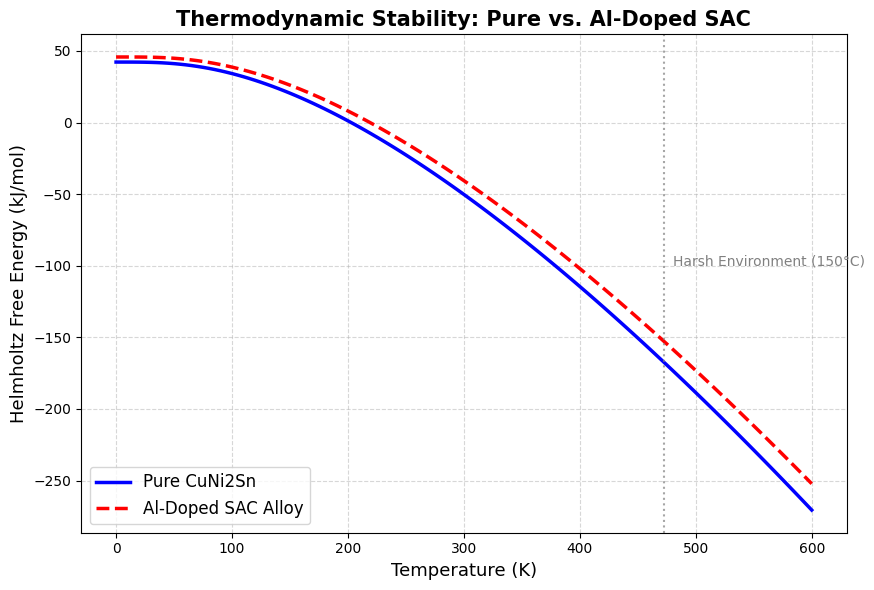

In [ ]:
import matplotlib.pyplot as plt

# Data from your results
temps = tp_pure['temperatures']
fe_pure = tp_pure['free_energy']
fe_doped = tp_doped['free_energy']

# 1. Plotting
plt.figure(figsize=(9, 6))
plt.plot(temps, fe_pure, color='blue', linewidth=2.5, label='Pure CuNi2Sn')
plt.plot(temps, fe_doped, color='red', linewidth=2.5, linestyle='--', label='Al-Doped SAC Alloy')

# 2. Styling
plt.title("Thermodynamic Stability: Pure vs. Al-Doped SAC", fontsize=15, fontweight='bold')
plt.xlabel("Temperature (K)", fontsize=13)
plt.ylabel("Helmholtz Free Energy (kJ/mol)", fontsize=13)
plt.axvline(x=473, color='gray', linestyle=':', alpha=0.7) # Harsh environment marker
plt.text(480, -100, 'Harsh Environment (150°C)', fontsize=10, color='gray')

plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()